# receptor ligand analysis 
# (1) using squidpy implementation of cellphonedb

In [2]:
import squidpy as sq
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
bdata = adata[adata.obs['compartment'].str.contains('orsal')]
bdata

replicates = {}
for rep in bdata.obs.batch_key.unique():
    replicates[rep] = bdata[bdata.obs.batch_key == rep].copy()

In [3]:
example_rep = replicates['D7IMQ_F3']

In [4]:
res = sq.gr.ligrec(
    example_rep,
    n_perms=1000,
    cluster_key="celltype_assignments",
    copy=True,
    use_raw=False,
    transmitter_params={"categories": "ligand"},
    receiver_params={"categories": "receptor"},
)

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1000/1000 [01:22<00:00, 12.12permutation/s]


In [10]:
res["pvalues"].head()

cluster_1     M2-like_macrophage                                          \
cluster_2     M2-like_macrophage activated_basal_KC activated_corneocyte   
source target                                                              
EPOR   TRPC3                 NaN                NaN                  NaN   
FYN    TRPC4                 NaN                NaN                  NaN   
       TRPC6                 NaN                NaN                  NaN   
       TRPV4               0.074                NaN                  NaN   
KL     TRPV5                 NaN                NaN                  NaN   

cluster_1                                                                   \
cluster_2     activated_intermediate_basal_suprabasal_KC activated_spinous   
source target                                                                
EPOR   TRPC3                                         NaN               NaN   
FYN    TRPC4                                         NaN               NaN   
       TRPC6                                         NaN               NaN   
       TRPV4                                       0.445             0.011   
KL     TRPV5                                         NaN               NaN   

cluster_1                                                            \
cluster_2     activated_suprabasal_KC adipocyte basal_KC corneocyte   
source target                                                         
EPOR   TRPC3                      NaN       NaN      NaN        NaN   
FYN    TRPC4                      NaN       NaN      NaN        NaN   
       TRPC6                      NaN       NaN      NaN        NaN   
       TRPV4                    0.398       NaN      NaN        NaN   
KL     TRPV5                      NaN       NaN      NaN        NaN   

cluster_1                        ...                    suprabasal_KC  \
cluster_2     dermal_fibroblast  ... intermediate_basal_suprabasal_KC   
source target                    ...                                    
EPOR   TRPC3                NaN  ...                              NaN   
FYN    TRPC4                NaN  ...                              NaN   
       TRPC6                NaN  ...                              NaN   
       TRPV4                NaN  ...                              NaN   
KL     TRPV5                NaN  ...                              NaN   

cluster_1                                                                \
cluster_2     late_activated_suprabasal_KC mast_cell myeloid neutrophil   
source target                                                             
EPOR   TRPC3                           NaN       NaN     NaN        NaN   
FYN    TRPC4                           NaN       NaN     NaN        NaN   
       TRPC6                           NaN       NaN     NaN        NaN   
       TRPV4                           NaN       NaN     NaN        NaN   
KL     TRPV5                           NaN       NaN     NaN        NaN   

cluster_1                                                                     \
cluster_2     perichondral_fibroblast schwann_cell sebaceous_epithelial  smc   
source target                                                                  
EPOR   TRPC3                      NaN          NaN                  NaN  NaN   
FYN    TRPC4                      NaN          NaN                  NaN  NaN   
       TRPC6                      NaN          NaN                  NaN  NaN   
       TRPV4                      NaN          NaN                  NaN  NaN   
KL     TRPV5                      NaN          NaN                  NaN  NaN   

cluster_1                    
cluster_2     suprabasal_KC  
source target                
EPOR   TRPC3            NaN  
FYN    TRPC4            NaN  
       TRPC6            NaN  
       TRPV4            NaN  
KL     TRPV5            NaN  

[5 rows x 484 columns]

In [11]:
res["metadata"].head()

aspect_intercell_source aspect_intercell_target  \
source target                                                   
EPOR   TRPC3               functional              functional   
FYN    TRPC4               functional              functional   
       TRPC6               functional              functional   
       TRPV4               functional              functional   
KL     TRPV5               functional              functional   

              category_intercell_source category_intercell_target  \
source target                                                       
EPOR   TRPC3                     ligand                  receptor   
FYN    TRPC4                     ligand                  receptor   
       TRPC6                     ligand                  receptor   
       TRPV4                     ligand                  receptor   
KL     TRPV5                     ligand                  receptor   

              category_source_intercell_source  \
source target                                    
EPOR   TRPC3                 resource_specific   
FYN    TRPC4                 resource_specific   
       TRPC6                 resource_specific   
       TRPV4                 resource_specific   
KL     TRPV5                 resource_specific   

              category_source_intercell_target  consensus_direction  \
source target                                                         
EPOR   TRPC3                 resource_specific                 True   
FYN    TRPC4                         composite                False   
       TRPC6                         composite                 True   
       TRPV4                 resource_specific                 True   
KL     TRPV5                         composite                 True   

               consensus_inhibition  consensus_score_intercell_source  \
source target                                                           
EPOR   TRPC3                  False                                 1   
FYN    TRPC4                  False                                 2   
       TRPC6                  False                                 2   
       TRPV4                  False                                 2   
KL     TRPV5                  False                                 3   

               consensus_score_intercell_target  ...  scope_intercell_source  \
source target                                    ...                           
EPOR   TRPC3                                  3  ...                 generic   
FYN    TRPC4                                  1  ...                 generic   
       TRPC6                                  1  ...                 generic   
       TRPV4                                  3  ...                 generic   
KL     TRPV5                                  1  ...                 generic   

               scope_intercell_target secreted_intercell_source  \
source target                                                     
EPOR   TRPC3                  generic                      True   
FYN    TRPC4                  generic                     False   
       TRPC6                  generic                     False   
       TRPV4                  generic                     False   
KL     TRPV5                  generic                      True   

              secreted_intercell_target  \
source target                             
EPOR   TRPC3                      False   
FYN    TRPC4                      False   
       TRPC6                      False   
       TRPV4                      False   
KL     TRPV5                      False   

                                              sources  \
source target                                           
EPOR   TRPC3                                     TRIP   
FYN    TRPC4                               TRIP;dbPTM   
       TRPC6   SPIKE_LC;HPRD;PhosphoPoint;TRIP;SIGNOR   
       TRPV4          SPIKE_LC;HPRD;PhosphoPoint;TRIP   
KL     TRPV5                          

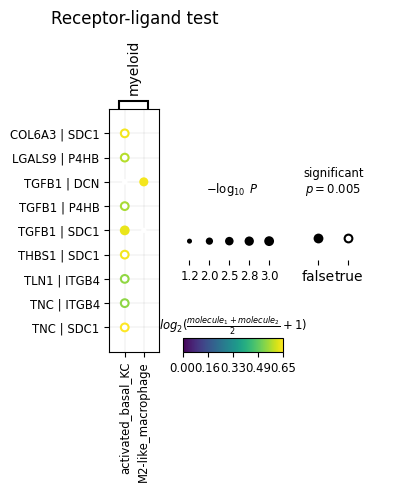

In [24]:
import matplotlib.pyplot as plt

sq.pl.ligrec(res, 
             source_groups = ["myeloid"], 
             target_groups = ['basal_KC', 'activated_basal_KC', 'M2-like_macrophage'], 
             remove_empty_interactions=True,
             remove_nonsig_interactions=True,
             means_range = (0.45,0.8),
             pvalue_threshold = 0.005,
             alpha=0.005,
             )


In [16]:
adata.layers

Layers with keys: counts, normalised

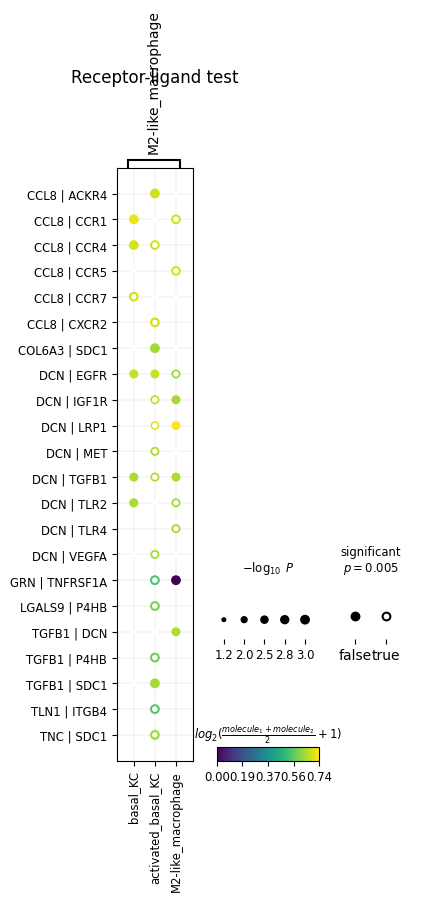

In [25]:
sq.pl.ligrec(res, 
             source_groups = ["M2-like_macrophage"], 
             target_groups = ['basal_KC', 'activated_basal_KC', 'M2-like_macrophage'], 
             remove_empty_interactions=True,
             remove_nonsig_interactions=True,
             means_range = (0.45,0.8),
             pvalue_threshold = 0.005,
             alpha=0.005,
             )

# ligand-receptor analysis using LARIS

In [1]:
#install Laris
#redo analysis with Laris, as spatial context may be better preserved and we can map it back onto domains etc
#also do morphology mapping

In [2]:
import scanpy as sc
import laris as la

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
bdata = adata[adata.obs['compartment'].str.contains('orsal')]
bdata

replicates = {}
for rep in bdata.obs.batch_key.unique():
    replicates[rep] = bdata[bdata.obs.batch_key == rep].copy()

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
sc.set_figure_params(dpi=96,dpi_save=300, color_map='viridis',facecolor='white')
plt.rcParams['figure.figsize'] = 4, 4
sc.settings.verbosity = 3
sc.logging.print_header()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_26236\145925768.py:4: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_header()


Package,Version
scanpy,1.11.5
laris,0.9.3
anndata,0.12.6
numpy,2.2.6
pandas,2.3.3
matplotlib,3.10.7
Component,Info
Python,"3.13.13 (tags/v3.13.13:01104ce, Apr 7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]"
OS,Windows-11-10.0.26100-SP0
CPU,"14 logical CPU cores, Intel64 Family 6 Model 170 Stepping 4, GenuineIntel"


In [5]:
import liana
from liana.resource import select_resource

#liana.resource.show_resources() use if you want to see other dfs available

# Get CellChatDB mouse interactions
lr_df = select_resource('mouseconsensus') #obtaining a mouse lig-rec dataframe
lr_df.head(2)

,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2


In [ ]:
from pathlib import Path
results_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\LARIS_results")

unfiltered_dfs = {}
interesting_dfs = {}

# looping over replicates
for name, adata in replicates.items():
    #filtering lig/recs not present in adata
    rows_keep = np.logical_and(lr_df['ligand'].isin(adata.var_names), lr_df['receptor'].isin(adata.var_names))
    lr_df_filtered = lr_df.loc[rows_keep].copy()

    #creating the ligand receptor anndata object for LARIS
    lr_adata = la.tl.prepareLRInteraction(
        adata,
        lr_df_filtered,
        number_nearest_neighbors = 15,
        use_rep_spatial = 'X_spatial'
    )

    #run LARIS
    warnings.filterwarnings("ignore")
    LARIS_variable_interactions, res_LARIS=la.tl.runLARIS(
        lr_adata,
        adata,
        use_rep='X_spatial',
        n_nearest_neighbors=15,
        random_seed=27,
        n_repeats=5,
        mu = 1, # larger value indicates more consideration for specificity
        sigma=100,#controls how quickly spatial weights decay with distance
        remove_lowly_expressed=True,
        expressed_pct=0.1,
        n_cells_expressed_threshold=100,
        n_top_lr=lr_adata.shape[1],

        by_celltype=True,
        ### Parameters for cell type-level inference when by_celltype set to True
        groupby='celltype_assignments', # label to group by
        use_rep_spatial='X_spatial', # spatial coordinates
        mu_celltype=100, # higher value puts more emphasis on cell type specificity
        expressed_pct_celltype=0.1, # expression percentage cut off per cell type
        remove_lowly_expressed_celltype=True,
        mask_threshold=1e-6, # mask for cosg, lower value is less restrictive
        n_neighbors_permutation=30,
        score_threshold= 1e-10,
        spatial_weight = 3.0,
    )

    #############################################################################
    #saving results
    LARIS_variable_interactions_path = results_path / (name + "variable_Ints.csv")
    LARIS_variable_interactions.to_csv(LARIS_variable_interactions_path) #df with interactions that occur

    res_LARIS_path = results_path / (name + "celltype_Res.csv")
    res_LARIS.to_csv(res_LARIS_path) #df with celltype specific interactions

    unfiltered_dfs[name] = [LARIS_variable_interactions, res_LARIS]
    #############################################################################


LARIS ANALYSIS

Input data: 1903 cells × 1625 LR pairs
Mode: Cell type-specific analysis

--- Step 1: Calculating spatial specificity scores ---
  - Using 15 nearest neighbors
  - Regularization parameter μ = 1
  - Random repeats: 5
  - Generating random permutations...
  ✓ Identified 1625 top spatially-specific LR pairs
  - Score range: [-0.0562, 0.5128]

CELL TYPE-SPECIFIC ANALYSIS

Analyzing 20 cell types from 'celltype_assignments'
Cell types: ['M2-like_macrophage', 'activated_basal_KC', 'activated_corneocyte', 'activated_suprabasal_KC', 'adipocyte', 'basal_KC', 'corneocyte', 'dermal_fibroblast', 'endothelial', 'follicle_cell']...

LARIS CELL TYPE ANALYSIS

--- Step 1: Calculating ligand and receptor cell type specificity ---
  ✓ Computed specificity for 855 genes across 20 cell types

--- Step 2: Calculating diffused LR-score distribution ---
  ✓ Computed diffused scores for 1625 interactions

--- Step 3: Computing interaction scores (spatial_weight=3.0) ---
  ✓ Processed 1625 in

  Processing pairs: 100%|██████████| 400/400 [01:16<00:00,  5.25it/s]


  ✓ Calculated p-values for 650,000 interaction combinations

--- Step 5.3: Applying FDR correction (Benjamini-Hochberg) ---
  - Strategy: Pre-filtered
  - Pre-filter threshold: 0.0


  FDR correction: 100%|██████████| 400/400 [00:00<00:00, 1013.37it/s]


  ✓ Corrected 400 sender-receiver pairs
  - Interactions tested: 280
  - Interactions filtered: 649,720

  Significant interactions:
  - FDR < 0.05: 240 (0.04%)
  - FDR < 0.01: 191 (0.03%)

STATISTICAL TESTING COMPLETE

LARIS CELL TYPE ANALYSIS COMPLETE

Final results: 650,000 sender-receiver-LR combinations
Score range: [0.000000, 1.701262]

ANALYSIS COMPLETE

Results summary:
  - Spatially-specific LR pairs: 1625
  - Cell type combinations: 650,000
  - Significant interactions (FDR < 0.05): 240

LARIS ANALYSIS

Input data: 1910 cells × 1625 LR pairs
Mode: Cell type-specific analysis

--- Step 1: Calculating spatial specificity scores ---
  - Using 15 nearest neighbors
  - Regularization parameter μ = 1
  - Random repeats: 5
  - Generating random permutations...
  ✓ Identified 1625 top spatially-specific LR pairs
  - Score range: [-0.0550, 0.5875]

CELL TYPE-SPECIFIC ANALYSIS

Analyzing 19 cell types from 'celltype_assignments'
Cell types: ['M2-like_macrophage', 'activated_basal_KC', 

...

  ✓ Corrected 441 sender-receiver pairs
  - Interactions tested: 1,935
  - Interactions filtered: 714,690

  Significant interactions:
  - FDR < 0.05: 727 (0.10%)
  - FDR < 0.01: 624 (0.09%)

STATISTICAL TESTING COMPLETE

LARIS CELL TYPE ANALYSIS COMPLETE

Final results: 716,625 sender-receiver-LR combinations
Score range: [0.000000, 31.068697]

ANALYSIS COMPLETE

Results summary:
  - Spatially-specific LR pairs: 1625
  - Cell type combinations: 716,625
  - Significant interactions (FDR < 0.05): 727

LARIS ANALYSIS

Input data: 4740 cells × 1625 LR pairs
Mode: Cell type-specific analysis

--- Step 1: Calculating spatial specificity scores ---
  - Using 15 nearest neighbors
  - Regularization parameter μ = 1
  - Random repeats: 5
  - Generating random permutations...
  ✓ Identified 1625 top spatially-specific LR pairs
  - Score range: [-0.0605, 0.6910]

CELL TYPE-SPECIFIC ANALYSIS

Analyzing 22 cell types from 'celltype_assignments'
Cell types: ['M2-like_macrophage', 'activated_basal_KC

  Processing pairs: 100%|██████████| 484/484 [01:57<00:00,  4.12it/s]


  ✓ Calculated p-values for 786,500 interaction combinations

--- Step 5.3: Applying FDR correction (Benjamini-Hochberg) ---
  - Strategy: Pre-filtered
  - Pre-filter threshold: 0.0


  FDR correction: 100%|██████████| 484/484 [00:01<00:00, 428.49it/s]


  ✓ Corrected 484 sender-receiver pairs
  - Interactions tested: 4,226
  - Interactions filtered: 782,274

  Significant interactions:
  - FDR < 0.05: 1,544 (0.20%)
  - FDR < 0.01: 1,391 (0.18%)

STATISTICAL TESTING COMPLETE

LARIS CELL TYPE ANALYSIS COMPLETE

Final results: 786,500 sender-receiver-LR combinations
Score range: [0.000000, 10.984439]

ANALYSIS COMPLETE

Results summary:
  - Spatially-specific LR pairs: 1625
  - Cell type combinations: 786,500
  - Significant interactions (FDR < 0.05): 1,544


## loading interaction dfs back in

In [153]:
#read results
from pathlib import Path
import pandas as pd

results_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\LARIS_results")

celltype_dfs = {}

for file in results_path.glob("*celltype_Res.csv"):
    celltype_dfs[file.stem.removesuffix('celltype_Res')] = pd.read_csv(file, index_col = 0)

len(celltype_dfs)


30

In [107]:
celltype_dfs['Ctrl_F1'].head(2)

,sender,receiver,interaction_score,ligand,receptor,interaction_name,p_value,p_value_fdr,nlog10_p_value_fdr
0,intermediate_basal_suprabasal_KC,sebaceous_epithelial,1.701262,Apoe,Abca1,Apoe::Abca1,0.000999,0.000999,3.000434
1,dermal_fibroblast,suprabasal_KC,1.654382,Col1a2,Sdc1,Col1a2::Sdc1,0.000999,0.001332,2.875496


In [25]:
import scanpy as sc
import laris as la

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
bdata = adata[adata.obs['compartment'].str.contains('orsal')]
bdata


View of AnnData object with n_obs × n_vars = 113483 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    var: 'gene_ids', 'feature_types'

In [44]:
cell_types = adata.obs.celltype_assignments.cat.categories
colours = adata.uns['celltype_assignments_colors']

master_colours = dict(zip(cell_types, colours))

replicates = {}
for rep in bdata.obs.batch_key.unique():
    rep_adata = bdata[bdata.obs.batch_key == rep].copy()


    rep_adata.obs['celltype_assignments'] = rep_adata.obs['celltype_assignments'].cat.remove_unused_categories()

    rep_categories = rep_adata.obs['celltype_assignments'].cat.categories

    rep_adata.uns['celltype_assignments_colors'] = [
        master_colours[ct] for ct in rep_categories
    ]

    replicates[rep] = rep_adata

## COMBINING REPLICATE TABLES, across replicates
### fishers test for combining p-values, recompute fdr. 
### interaction_score is log1p

In [154]:
#first, filter out 0 interaction scores 

celltype_dfs 
celltype_dfs_filtered = {}

fdr_threshold = 0.05

#process individual replicate dataframes. 
for name, df in celltype_dfs.items():

    df_nonzero = df[df['interaction_score'] >0] #remove 0 score interactions
    
    #winsorize to reduce effect of random high interaction scores - can remove if they might be biologically relevant, but I think Apoe:Abca1 was not in this case
    cap = df_nonzero['interaction_score'].quantile(0.99)
    
    #log transform interaction scores
    df_nonzero['interaction_score'] = np.log(df_nonzero['interaction_score'].clip(upper = cap)) #transforming the clipped version

    #add to filtered dictionary
    celltype_dfs_filtered[name] = df_nonzero

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_5336\4183523987.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonzero['interaction_score'] = np.log(df_nonzero['interaction_score'].clip(upper = cap)) #transforming the clipped version
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_5336\4183523987.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonzero['interaction_score'] = np.log(df_nonzero['interaction_score'].clip(upper = cap)) #transforming the clipped version
C:\Users\dbuxton\AppData\Local

In [155]:
#now combine replicates from different tables
##interaction score --> geometric mean (i.e. average of log transformed scores, then reverse the log)
##p value --> combined using Fishers method for combining p-Values

from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests
import numpy as np

condition_dfs = {}

from itertools import groupby

def get_condition_sex(name):
    return name.rstrip('0123456789')

#create condition groups (e.g. Ctrl_F, D7IMQ_M etc)
groups = {}
for name in celltype_dfs_filtered.keys():
    key = get_condition_sex(name)
    groups.setdefault(key, []).append(name)

for condition_sex, replicate_names in groups.items():
    dfs = [celltype_dfs_filtered[n].assign(replicate=n) for n in replicate_names]
    combined = pd.concat(dfs)

    groupby_cols = ['sender', 'receiver', 'interaction_name', 'ligand', 'receptor']

    def aggregate_group(g):
        #fishers method for combining p_values. 
        pvals = g['p_value'].values
        if len(pvals) > 1:
            _, combined_p = combine_pvalues(pvals, method = 'fisher')
        else:
            combined_p = pvals[0]

        return pd.Series({
            'interaction_score': np.exp(g['interaction_score'].mean()), #reverse logtransform, put back in original 'units', basically a geometric mean
            'interaction_score_std':g['interaction_score'].std(),
            'n_replicates': len(g),
            'n_sig_replicates': (g['p_value_fdr'] < fdr_threshold).sum(),
            'p_value': combined_p
        })
    
    result = (combined
               .groupby(groupby_cols)
               .apply(aggregate_group)
               .reset_index()
               )
    
    #recompute FDR on the combined p-values
    _, result['p_value_fdr'], _, _ = multipletests(
        result['p_value'], method = 'fdr_bh'
    )
    result['nlog10_p_value_fdr'] = -np.log10(result['p_value_fdr'])

    #filter out conditions where only 1 replicate displayed a certain interaction
    result = result[result['n_replicates'] > 1]

    condition_dfs[condition_sex] = result

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_5336\152647392.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregate_group)
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_5336\152647392.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregate_group)
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_5336\152647392.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This

In [157]:
#save the results
results_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\LARIS_results\combined_tables")

for name, df in condition_dfs.items():
    path = results_path / (name + ".csv")
    df.to_csv(path)

## Analysing immune|basalKC/fibroblast interactions in combined tables

In [ ]:
from pathlib import Path
import pandas as pd

results_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\LARIS_results\combined_tables")

condition_dfs = {}

for file in results_path.glob("*.csv"):
    condition_dfs[file.stem] = pd.read_csv(file, index_col=0)

In [178]:
celltypes_of_interest = ['myeloid', 'M2-like_macrophage', 'dermal_fibroblast', 'basal_KC', 'activated_basal_KC']

interactions_of_interest = {}

for name, df in condition_dfs.items():
    filtered = df[
        df['sender'].isin(celltypes_of_interest) &
        df['receiver'].isin(celltypes_of_interest) &
        (df['sender'] != df['receiver'])
    ]
    
    interactions_of_interest[name] = filtered

In [179]:
#save the results
results_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\LARIS_results\combined_tables")

for name, df in interactions_of_interest.items():
    path = results_path / (name + "_interactions_of_interest.csv")
    df.to_csv(path)

In [176]:
interactions_of_interest['D3IMQ_F']

,sender,receiver,interaction_name,ligand,receptor,interaction_score,interaction_score_std,n_replicates,n_sig_replicates,p_value,p_value_fdr,nlog10_p_value_fdr
0,M2-like_macrophage,M2-like_macrophage,Apoe::Abca1,Apoe,Abca1,0.000092,1.808253,2.0,2.0,1.478792e-05,9.263417e-05,4.033229
1,M2-like_macrophage,M2-like_macrophage,Apoe::Lrp1,Apoe,Lrp1,0.000011,4.327179,4.0,4.0,8.977971e-08,3.024892e-06,5.519290
3,M2-like_macrophage,M2-like_macrophage,F13a1::Itgb1,F13a1,Itgb1,0.008117,0.909214,2.0,2.0,1.478792e-05,9.263417e-05,4.033229
6,M2-like_macrophage,activated_basal_KC,Apoe::Ldlr,Apoe,Ldlr,0.000910,1.838593,2.0,1.0,2.324165e-02,3.863176e-02,1.413055
8,M2-like_macrophage,activated_basal_KC,Apoe::Lsr,Apoe,Lsr,0.000004,5.085591,3.0,1.0,7.198047e-03,1.339105e-02,1.873185
...,...,...,...,...,...,...,...,...,...,...,...,...
3541,myeloid,basal_KC,Col1a2::Cd44,Col1a2,Cd44,0.001721,0.668555,2.0,2.0,1.478792e-05,9.263417e-05,4.033229
3542,myeloid,basal_KC,Col1a2::Sdc1,Col1a2,Sdc1,0.000628,1.474676,3.0,3.0,2.358072e-07,3.692846e-06,5.432639
3547,myeloid,basal_KC,Pkm::Cd44,Pkm,Cd44,0.003695,0.489673,2.0,1.0,1.086939e-02,1.957889e-02,1.708212
3548,myeloid,basal_KC,Vim::Cd44,Vim,Cd44,0.072250,1.714752,4.0,4.0,3.912261e-09,1.804369e-07,6.743675


## Identifying interactions unique to a certain celltype

In [167]:
def find_unique_interactions(df, celltypes):
    
    # interactions where at least one side is in the celltype list
    celltype_interactions = df[
        df['sender'].isin(celltypes) | df['receiver'].isin(celltypes)
    ]
    
    # interaction_names that occur between two cells both outside the celltype list
    non_celltype_interaction_names = df[
        ~df['sender'].isin(celltypes) & ~df['receiver'].isin(celltypes)
    ]['interaction_name'].unique()
    
    # keep only interactions not found in the non-celltype set
    unique = celltype_interactions[
        ~celltype_interactions['interaction_name'].isin(non_celltype_interaction_names)
    ]
    
    return unique.reset_index(drop=True)

In [172]:
myeloid_unique = {}

for name, df in condition_dfs.items():
    myeloid_unique[name] = find_unique_interactions(df, ['myeloid', 'M2-macrophage'])
    print(name)
    print(myeloid_unique[name][['sender', 'receiver', 'interaction_name', 'interaction_score', 'n_sig_replicates', 'p_value_fdr']])

Ctrl_F
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D10IMQ_F
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
Ctrl_M
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D10IMQ_M
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D3IMQ_F
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D3IMQ_M
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D7IMQ_F
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D7IMQ_M
                                       sender receiver interaction_name  \
0      

In [169]:
def find_shared_interactions(df, celltype_pair):
    
    cell_a, cell_b = celltype_pair
    
    # get interaction_names that occur between this specific pair
    pair_interaction_names = df[
        ((df['sender'] == cell_a) & (df['receiver'] == cell_b)) |
        ((df['sender'] == cell_b) & (df['receiver'] == cell_a))
    ]['interaction_name'].unique()
    
    # return all rows where those interaction_names appear, regardless of pairing
    shared = df[df['interaction_name'].isin(pair_interaction_names)]
    
    return shared.reset_index(drop=True)

In [170]:
non_unique = {}

for name, df in condition_dfs.items():
    non_unique[name] = find_unique_interactions(df, ['myeloid', 'activated_basal_KC'])
    print(name)
    print(non_unique[name][['sender', 'receiver', 'interaction_name', 'interaction_score', 'n_sig_replicates', 'p_value_fdr']])

Ctrl_F
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D10IMQ_F
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
Ctrl_M
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D10IMQ_M
Empty DataFrame
Columns: [sender, receiver, interaction_name, interaction_score, n_sig_replicates, p_value_fdr]
Index: []
D3IMQ_F
                     sender                                    receiver  \
0        M2-like_macrophage                          activated_basal_KC   
1        activated_basal_KC                          activated_basal_KC   
2        activated_basal_KC                          activated_basal_KC   
3        activated_basal_KC  activated_intermediate_basal_suprabasal_KC   
4        activated_basal_KC  activated_intermediate_basal_suprabasal_KC   
5        activated_bas

In [180]:
condition = 'D3IMQ_F'

df = condition_dfs[condition]

find_shared_interactions(df, ['myeloid', 'dermal_fibroblast'])

,sender,receiver,interaction_name,ligand,receptor,interaction_score,interaction_score_std,n_replicates,n_sig_replicates,p_value,p_value_fdr,nlog10_p_value_fdr
0,M2-like_macrophage,M2-like_macrophage,Apoe::Lrp1,Apoe,Lrp1,0.000011,4.327179,4.0,4.0,8.977971e-08,3.024892e-06,5.519290
1,M2-like_macrophage,activated_intermediate_basal_suprabasal_KC,Apoe::Lrp1,Apoe,Lrp1,0.002175,2.185719,2.0,0.0,1.601347e-02,2.779508e-02,1.556032
2,M2-like_macrophage,activated_suprabasal_KC,Apoe::Lrp1,Apoe,Lrp1,0.000685,1.578313,4.0,1.0,5.916218e-03,1.109489e-02,1.954877
3,M2-like_macrophage,adipocyte,Apoe::Lrp1,Apoe,Lrp1,0.004785,2.086903,2.0,2.0,1.478792e-05,9.263417e-05,4.033229
4,M2-like_macrophage,dermal_fibroblast,Apoe::Lrp1,Apoe,Lrp1,0.000023,3.821742,4.0,4.0,3.912261e-09,1.804369e-07,6.743675
...,...,...,...,...,...,...,...,...,...,...,...,...
95,suprabasal_KC,activated_intermediate_basal_suprabasal_KC,Apoe::Lrp1,Apoe,Lrp1,0.002272,1.067095,3.0,0.0,6.795969e-02,8.506615e-02,1.070243
96,suprabasal_KC,activated_suprabasal_KC,Apoe::Lrp1,Apoe,Lrp1,0.002625,0.890377,4.0,0.0,2.655713e-02,4.317092e-02,1.364809
97,suprabasal_KC,dermal_fibroblast,Apoe::Lrp1,Apoe,Lrp1,0.025725,0.369301,4.0,4.0,3.912261e-09,1.804369e-07,6.743675
98,suprabasal_KC,myeloid,Apoe::Lrp1,Apoe,Lrp1,0.010645,1.645409,3.0,3.0,1.212915e-04,6.724707e-04,3.172327


In [201]:
condition = 'D7IMQ_M'

df = condition_dfs[condition]

find_unique_interactions(df, ['myeloid']).sort_values(by = 'interaction_score', ascending = False)

,sender,receiver,interaction_name,ligand,receptor,interaction_score,interaction_score_std,n_replicates,n_sig_replicates,p_value,p_value_fdr,nlog10_p_value_fdr
6,neutrophil,myeloid,Selplg::Itgam,Selplg,Itgam,0.041068,1.302806,2.0,2.0,0.000015,0.000106,3.975271
4,dermal_fibroblast,myeloid,C3::Itgam,C3,Itgam,0.016640,1.301524,2.0,2.0,0.000015,0.000106,3.975271
3,basal_KC,myeloid,Selplg::Itgam,Selplg,Itgam,0.001596,0.520483,2.0,2.0,0.000015,0.000106,3.975271
2,adipocyte,myeloid,C3::Itgam,C3,Itgam,0.000390,5.864653,2.0,2.0,0.000015,0.000106,3.975271
5,mast_cell,myeloid,Plau::Itgam,Plau,Itgam,0.000101,1.692013,2.0,2.0,0.000015,0.000106,3.975271
0,activated_basal_KC,myeloid,Plau::Itgam,Plau,Itgam,0.000020,0.570278,2.0,2.0,0.000015,0.000106,3.975271
1,activated_intermediate_basal_suprabasal_KC,myeloid,Plau::Itgam,Plau,Itgam,0.000014,0.067427,2.0,2.0,0.000015,0.000106,3.975271


In [ ]:
condition = 'D7IMQ_F'

df = condition_dfs[condition]

unique = find_unique_interactions(df, ['myeloid', 'M2-like_macrophage', 'neutrophil', 'dermal_fibroblast'])
unique[(unique['sender'] == 'myeloid') | (unique['receiver'] == 'myeloid')]

,sender,receiver,interaction_name,ligand,receptor,interaction_score,interaction_score_std,n_replicates,n_sig_replicates,p_value,p_value_fdr,nlog10_p_value_fdr
128,myeloid,M2-like_macrophage,Pltp::Abca1,Pltp,Abca1,0.048425,0.879676,2.0,2.0,1.478792e-05,1.306464e-04,3.883902
129,myeloid,adipocyte,Pltp::Abca1,Pltp,Abca1,0.002670,3.004706,2.0,2.0,1.478792e-05,1.306464e-04,3.883902
130,myeloid,neutrophil,Apoe::Sorl1,Apoe,Sorl1,0.002560,2.088793,2.0,2.0,1.478792e-05,1.306464e-04,3.883902
131,myeloid,sebaceous_epithelial,Pltp::Abca1,Pltp,Abca1,0.002424,2.818860,4.0,4.0,3.912261e-09,5.850608e-07,6.232799


## plotting networks

In [131]:
test = condition_dfs['D3IMQ_F']
test['p_value_fdr'] = test['p_value_fdr_combined']
test = test[test['n_replicates'] >1]

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\laris\plotting\__init__.py:895: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


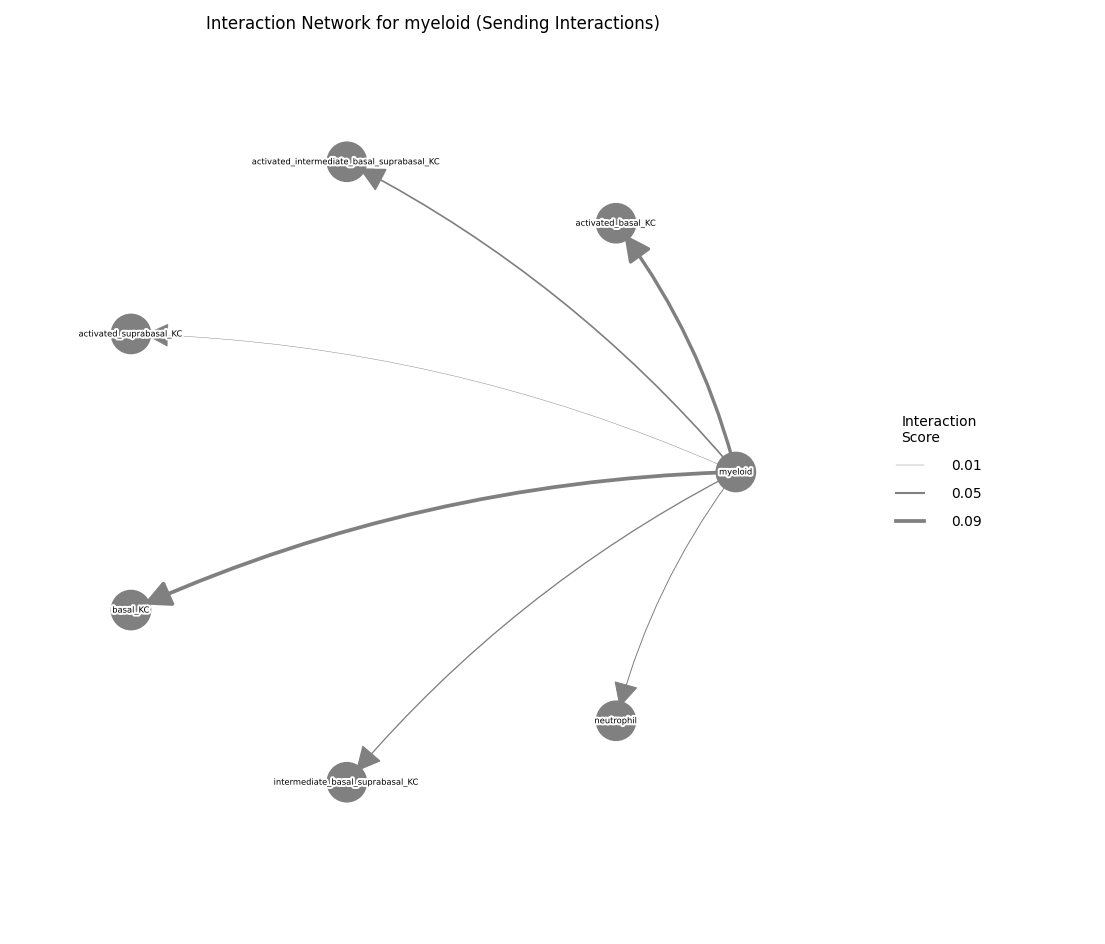

<Figure size 640x480 with 0 Axes>

In [132]:
import matplotlib.pyplot as plt


la.pl.plotCCCNetwork(
    test,
    'myeloid',
    interaction_direction='sending',
    interaction_cutoff = -5,
    threshold = 0.1,
    # ── Spacing Optimization Arguments ──────────────────────────────────
    margins=0.2,            # Bumps up layout padding (Default is 0.2)
    node_size=800,           # Shrinks node diameter slightly (Default is 1100)
    label_font_size=6,      # Prevents long cell names from colliding (Default is 16)
    figsize=(14, 12)         # Giving the overall canvas more room to stretch
)

# Force matplotlib to clean up any residual text bounding box overlaps
plt.tight_layout()
plt.show()

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\laris\plotting\__init__.py:895: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


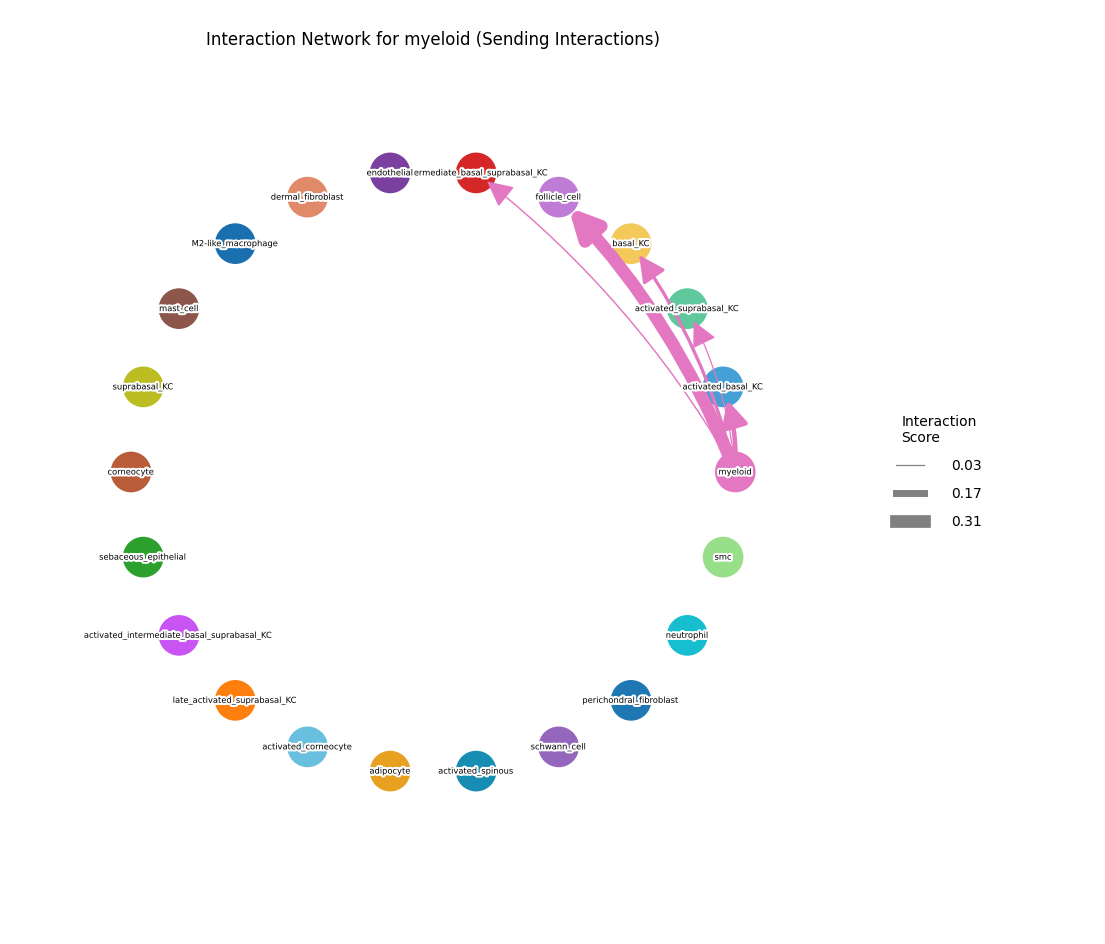

<Figure size 640x480 with 0 Axes>

In [53]:
import matplotlib.pyplot as plt

rep = 'D3IMQ_F1'

la.pl.plotCCCNetwork(
    celltype_dfs[rep],
    'myeloid',
    interaction_direction='sending',
    adata=replicates[rep],
    groupby='celltype_assignments',
    custom_color_mapping=master_colours,
    
    # ── Spacing Optimization Arguments ──────────────────────────────────
    margins=0.2,            # Bumps up layout padding (Default is 0.2)
    node_size=800,           # Shrinks node diameter slightly (Default is 1100)
    label_font_size=6,      # Prevents long cell names from colliding (Default is 16)
    figsize=(14, 12)         # Giving the overall canvas more room to stretch
)

# Force matplotlib to clean up any residual text bounding box overlaps
plt.tight_layout()
plt.show()